In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as XLImage

In [3]:
xls = pd.ExcelFile('/content/PrimeRx Datasets.xlsx')

print(xls.sheet_names)

['Alerts', 'Sales', 'Affiliation']


In [4]:
alerts = pd.read_excel('/content/PrimeRx Datasets.xlsx', sheet_name='Alerts')

sales = pd.read_excel('/content/PrimeRx Datasets.xlsx', sheet_name='Sales')

affiliation = pd.read_excel('/content/PrimeRx Datasets.xlsx', sheet_name='Affiliation')

In [5]:
print("ALERTS")
display(alerts.head())

print("\nSALES")
display(sales.head())

print("\nAFFILIATION")
display(affiliation.head())

ALERTS


,Alert_ID,Alert_Date,HCP_ID,Lab_Result
0,ALT001134,2024-03-07,HCP009,Negative
1,ALT008550,2024-10-15,HCP109,Negative
2,ALT008560,2023-07-01,HCP110,Positive
3,ALT006177,2023-12-04,HCP045,Negative
4,ALT008377,2023-07-01,HCP105,Positive



SALES


,Prescription_ID,Prescription_Date,HCP_ID,Drug_Name,Drug_ID,Prescription_Volume
0,RX004327,2024-12-31,HCP159,Rivalex,DRG002,22
1,RX005835,2024-12-31,HCP217,Rivalex,DRG002,46
2,RX004207,2024-12-31,HCP156,Nexavir,DRG001,27
3,RX004120,2024-12-31,HCP154,Rivalex,DRG002,44
4,RX002489,2024-12-31,HCP095,Nexavir,DRG001,17



AFFILIATION


,HCP_ID,Account_ID,Account_Name
0,HCP001,ACC001,Northside General Hospital
1,HCP002,ACC001,Northside General Hospital
2,HCP003,ACC001,Northside General Hospital
3,HCP004,ACC001,Northside General Hospital
4,HCP005,ACC001,Northside General Hospital


In [6]:
print("Alerts Shape:", alerts.shape)
print("Sales Shape:", sales.shape)
print("Affiliation Shape:", affiliation.shape)

Alerts Shape: (9537, 4)
Sales Shape: (5917, 6)
Affiliation Shape: (216, 3)


In [7]:
print("Alerts Columns")
print(alerts.columns.tolist())

print("\nSales Columns")
print(sales.columns.tolist())

print("\nAffiliation Columns")
print(affiliation.columns.tolist())

Alerts Columns
['Alert_ID', 'Alert_Date', 'HCP_ID', 'Lab_Result']

Sales Columns
['Prescription_ID', 'Prescription_Date', 'HCP_ID', 'Drug_Name', 'Drug_ID', 'Prescription_Volume']

Affiliation Columns
['HCP_ID', 'Account_ID', 'Account_Name']


In [8]:
print(alerts.dtypes)

print(sales.dtypes)

print(affiliation.dtypes)

Alert_ID              object
Alert_Date    datetime64[ns]
HCP_ID                object
Lab_Result            object
dtype: object
Prescription_ID                object
Prescription_Date      datetime64[ns]
HCP_ID                         object
Drug_Name                      object
Drug_ID                        object
Prescription_Volume             int64
dtype: object
HCP_ID          object
Account_ID      object
Account_Name    object
dtype: object


In [9]:
print("Alerts Missing Values")
print(alerts.isnull().sum())

print("\nSales Missing Values")
print(sales.isnull().sum())

print("\nAffiliation Missing Values")
print(affiliation.isnull().sum())

Alerts Missing Values
Alert_ID      0
Alert_Date    0
HCP_ID        0
Lab_Result    0
dtype: int64

Sales Missing Values
Prescription_ID        0
Prescription_Date      0
HCP_ID                 0
Drug_Name              0
Drug_ID                0
Prescription_Volume    0
dtype: int64

Affiliation Missing Values
HCP_ID          0
Account_ID      0
Account_Name    0
dtype: int64


In [10]:
alert_hcps = alerts['HCP_ID'].unique()
print("Doctors in Alert Universe:", len(alert_hcps))

Doctors in Alert Universe: 220


In [11]:
sales_alert_universe = sales[
    sales['HCP_ID'].isin(alert_hcps)
]

print("Original Sales Rows:", len(sales))
print("Filtered Sales Rows:", len(sales_alert_universe))

Original Sales Rows: 5917
Filtered Sales Rows: 5917


In [12]:
#Q1
#Part A.


In [13]:
top_alerts = (alerts.groupby('HCP_ID')['Alert_ID'].count().reset_index())

In [14]:
top_alerts.columns = ['HCP_ID', 'Total_Alerts']

In [15]:
top_alerts = top_alerts.sort_values(
    by='Total_Alerts',
    ascending=False
)

In [16]:
top10_alerts = top_alerts.head(10)

top10_alerts

,HCP_ID,Total_Alerts
40,HCP041,200
10,HCP011,198
18,HCP019,190
19,HCP020,188
31,HCP032,188
20,HCP021,185
13,HCP014,178
35,HCP036,176
21,HCP022,175
6,HCP007,173


In [17]:
top10_alerts = top10_alerts.reset_index(drop=True)

top10_alerts.insert(0,'Rank', range(1,11))

top10_alerts

,Rank,HCP_ID,Total_Alerts
0,1,HCP041,200
1,2,HCP011,198
2,3,HCP019,190
3,4,HCP020,188
4,5,HCP032,188
5,6,HCP021,185
6,7,HCP014,178
7,8,HCP036,176
8,9,HCP022,175
9,10,HCP007,173


In [18]:
#Part B.

In [19]:
top_rx = (sales.groupby('HCP_ID')['Prescription_Volume'].sum().reset_index())

In [20]:
top_rx.columns = ['HCP_ID','Total_Prescription_Volume']

In [21]:
top_rx = top_rx.sort_values(by='Total_Prescription_Volume',
    ascending=False
)

In [22]:
top10_rx = top_rx.head(10)

In [23]:
top10_rx = top10_rx.reset_index(drop=True)

top10_rx.insert(0,'Rank',range(1,11)
)

top10_rx

,Rank,HCP_ID,Total_Prescription_Volume
0,1,HCP185,2900
1,2,HCP062,2380
2,3,HCP019,2277
3,4,HCP163,2233
4,5,HCP126,2196
5,6,HCP211,2196
6,7,HCP154,2187
7,8,HCP215,2155
8,9,HCP088,2084
9,10,HCP004,2081


In [24]:
#Saving to excel file-

In [25]:
with pd.ExcelWriter('Case_Study_Output.xlsx') as writer:
    top10_alerts.to_excel(
        writer,
        sheet_name='Q1_Top_Alerts',
        index=False
    )

    top10_rx.to_excel(writer, sheet_name='Q1_Top_Rx',
        index=False
    )

print("Q1 saved. ")

Q1 saved. 


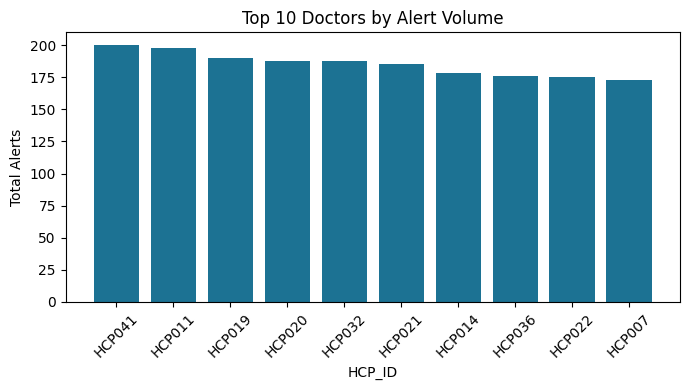

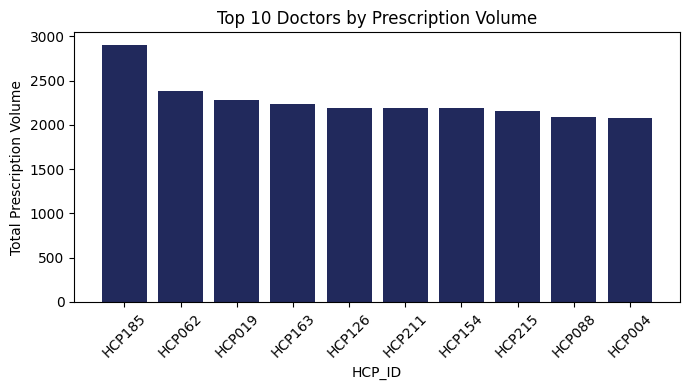

Q1 charts added.


In [26]:
# Q1 Charts
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(top10_alerts['HCP_ID'], top10_alerts['Total_Alerts'], color='#1C7293')
ax.set_title('Top 10 Doctors by Alert Volume')
ax.set_xlabel('HCP_ID'); ax.set_ylabel('Total Alerts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('q1_alerts_chart.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(7,4))
ax.bar(top10_rx['HCP_ID'], top10_rx['Total_Prescription_Volume'], color='#21295C')
ax.set_title('Top 10 Doctors by Prescription Volume')
ax.set_xlabel('HCP_ID'); ax.set_ylabel('Total Prescription Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('q1_rx_chart.png', dpi=150)
plt.show()

# Insert into the already-saved Excel file
wb = load_workbook('Case_Study_Output.xlsx')
ws1 = wb['Q1_Top_Alerts']
ws1.add_image(XLImage('q1_alerts_chart.png'), 'F2')

ws2 = wb['Q1_Top_Rx']
ws2.add_image(XLImage('q1_rx_chart.png'), 'F2')

wb.save('Case_Study_Output.xlsx')
print("Q1 charts added.")

In [27]:
#Q2.

In [28]:
alerts['Lab_Result'].value_counts()

,count
Lab_Result,
Negative,5111
Positive,4426


In [29]:
positive_alerts = alerts[alerts['Lab_Result'] == 'Positive']

print("Positive Alert Rows:", len(positive_alerts))

Positive Alert Rows: 4426


In [30]:
first_positive = (positive_alerts.groupby('HCP_ID')['Alert_Date'].min()
.reset_index()
)

first_positive.columns = ['HCP_ID','First_Positive_Alert_Date']

first_positive.head()

,HCP_ID,First_Positive_Alert_Date
0,HCP001,2023-07-02
1,HCP002,2023-07-09
2,HCP003,2023-07-12
3,HCP004,2023-07-01
4,HCP005,2023-07-05


In [31]:
stage1 = first_positive['HCP_ID'].nunique()

print(stage1)

214


In [32]:
positive_alert_count = (positive_alerts.groupby('HCP_ID')['Alert_ID'].count().reset_index())

positive_alert_count.columns = ['HCP_ID','Positive_Alerts'
]

positive_alert_count.head()

,HCP_ID,Positive_Alerts
0,HCP001,63
1,HCP002,59
2,HCP003,49
3,HCP004,49
4,HCP005,54


In [33]:
positive_hcp_summary = first_positive.merge(positive_alert_count,on='HCP_ID',how='left')

positive_hcp_summary.head()

,HCP_ID,First_Positive_Alert_Date,Positive_Alerts
0,HCP001,2023-07-02,63
1,HCP002,2023-07-09,59
2,HCP003,2023-07-12,49
3,HCP004,2023-07-01,49
4,HCP005,2023-07-05,54


In [34]:
rx_within_30_days = []

In [35]:
for _, row in positive_hcp_summary.iterrows():

    hcp = row['HCP_ID']

    first_date = row['First_Positive_Alert_Date']

    end_date = first_date + pd.Timedelta(days=30)

    hcp_sales = sales[(sales['HCP_ID'] == hcp)&(sales['Prescription_Date'] >= first_date)&(sales['Prescription_Date'] <= end_date)]

    rx_within_30_days.append(len(hcp_sales))

In [36]:
positive_hcp_summary['Rx_Within_30_Days'] = rx_within_30_days

positive_hcp_summary.head()

,HCP_ID,First_Positive_Alert_Date,Positive_Alerts,Rx_Within_30_Days
0,HCP001,2023-07-02,63,0
1,HCP002,2023-07-09,59,0
2,HCP003,2023-07-12,49,3
3,HCP004,2023-07-01,49,3
4,HCP005,2023-07-05,54,2


In [37]:
positive_hcp_summary['No_Rx_Within_30_Days'] = (positive_hcp_summary['Rx_Within_30_Days'] == 0
)

In [38]:
missed_doctors = positive_hcp_summary[positive_hcp_summary['No_Rx_Within_30_Days']]

print("Doctors with No Rx in 30 Days:",len(missed_doctors)
)

Doctors with No Rx in 30 Days: 77


In [39]:
missed_doctors.head()

,HCP_ID,First_Positive_Alert_Date,Positive_Alerts,Rx_Within_30_Days,No_Rx_Within_30_Days
0,HCP001,2023-07-02,63,0,True
1,HCP002,2023-07-09,59,0,True
6,HCP007,2023-07-01,96,0,True
8,HCP009,2023-07-11,67,0,True
10,HCP011,2023-07-01,123,0,True


In [40]:
top10_missed = (missed_doctors.sort_values(by='Positive_Alerts',ascending=False).head(10))

In [41]:
top10_missed = top10_missed.reset_index(drop=True)

top10_missed.insert(0,'Rank',range(1,11))

top10_missed[['Rank','HCP_ID','Positive_Alerts']]

,Rank,HCP_ID,Positive_Alerts
0,1,HCP041,127
1,2,HCP011,123
2,3,HCP021,116
3,4,HCP042,101
4,5,HCP023,99
5,6,HCP007,96
6,7,HCP026,78
7,8,HCP009,67
8,9,HCP001,63
9,10,HCP002,59


In [42]:
stage2 = (positive_hcp_summary[positive_hcp_summary['Positive_Alerts'] > 1]['HCP_ID'].nunique()
)

print(stage2)

198


In [43]:
stage3 = (positive_hcp_summary[(positive_hcp_summary['Positive_Alerts'] > 1)&(positive_hcp_summary['No_Rx_Within_30_Days'])]['HCP_ID'].nunique())

print(stage3)

68


In [44]:
funnel = pd.DataFrame({'Stage':['At least 1 Positive Alert','Multiple Positive Alerts',
        'Multiple Positive Alerts + No Rx' ],'Doctors':[stage1, stage2, stage3]
})

funnel

,Stage,Doctors
0,At least 1 Positive Alert,214
1,Multiple Positive Alerts,198
2,Multiple Positive Alerts + No Rx,68


In [45]:
#Q3.

In [46]:
top10_hcps = top10_alerts['HCP_ID'].tolist()

top10_hcps

['HCP041',
 'HCP011',
 'HCP019',
 'HCP020',
 'HCP032',
 'HCP021',
 'HCP014',
 'HCP036',
 'HCP022',
 'HCP007']

In [47]:
top10_sales = sales[sales['HCP_ID'].isin(top10_hcps)]

top10_sales.head()

,Prescription_ID,Prescription_Date,HCP_ID,Drug_Name,Drug_ID,Prescription_Volume
16,RX000516,2024-12-30,HCP019,Nexavir,DRG001,41
21,RX000574,2024-12-29,HCP022,Omniphar,DRG003,54
33,RX001025,2024-12-28,HCP036,Celudrin,DRG004,52
46,RX000835,2024-12-27,HCP032,Nexavir,DRG001,48
108,RX000515,2024-12-22,HCP019,Nexavir,DRG001,44


In [48]:
total_rx = (top10_sales.groupby('HCP_ID')['Prescription_Volume'].sum().reset_index())

total_rx.columns = ['HCP_ID','Total_Prescription_Volume']

total_rx

,HCP_ID,Total_Prescription_Volume
0,HCP014,944
1,HCP019,2277
2,HCP020,570
3,HCP022,1363
4,HCP032,2075
5,HCP036,1895


In [49]:
our_drug = (top10_sales[top10_sales['Drug_ID'] == 'DRG001'].groupby('HCP_ID')['Prescription_Volume'].sum().reset_index())

our_drug.columns = ['HCP_ID','Our_Drug_Volume']

our_drug

,HCP_ID,Our_Drug_Volume
0,HCP014,671
1,HCP019,1346
2,HCP020,145
3,HCP022,845
4,HCP032,1227
5,HCP036,1227


In [50]:
q3_table = total_rx.merge(our_drug, on='HCP_ID',how='left')

q3_table['Our_Drug_Volume'] = (q3_table['Our_Drug_Volume'].fillna(0))

q3_table.head()

,HCP_ID,Total_Prescription_Volume,Our_Drug_Volume
0,HCP014,944,671
1,HCP019,2277,1346
2,HCP020,570,145
3,HCP022,1363,845
4,HCP032,2075,1227


In [51]:
q3_table['Competitor_Volume'] = (q3_table['Total_Prescription_Volume']
    -q3_table['Our_Drug_Volume'])

In [52]:
q3_table['Our_Drug_Share_%'] = (q3_table['Our_Drug_Volume']
    /q3_table['Total_Prescription_Volume']* 100).round(2)

q3_table['Competitor_Share_%'] = (q3_table['Competitor_Volume']
    /q3_table['Total_Prescription_Volume']* 100).round(2)

In [53]:
rank_map = top10_alerts[['Rank','HCP_ID']]

q3_table = rank_map.merge(q3_table,on='HCP_ID')

q3_table

,Rank,HCP_ID,Total_Prescription_Volume,Our_Drug_Volume,Competitor_Volume,Our_Drug_Share_%,Competitor_Share_%
0,3,HCP019,2277,1346,931,59.11,40.89
1,4,HCP020,570,145,425,25.44,74.56
2,5,HCP032,2075,1227,848,59.13,40.87
3,7,HCP014,944,671,273,71.08,28.92
4,8,HCP036,1895,1227,668,64.75,35.25
5,9,HCP022,1363,845,518,62.00,38.00


In [54]:
table1 = q3_table[
    [
        'Rank',
        'HCP_ID',
        'Total_Prescription_Volume',
        'Our_Drug_Share_%',
        'Competitor_Share_%'
    ]
]

table1

,Rank,HCP_ID,Total_Prescription_Volume,Our_Drug_Share_%,Competitor_Share_%
0,3,HCP019,2277,59.11,40.89
1,4,HCP020,570,25.44,74.56
2,5,HCP032,2075,59.13,40.87
3,7,HCP014,944,71.08,28.92
4,8,HCP036,1895,64.75,35.25
5,9,HCP022,1363,62.00,38.00


In [55]:
top10_alerts[['Rank','HCP_ID']]

,Rank,HCP_ID
0,1,HCP041
1,2,HCP011
2,3,HCP019
3,4,HCP020
4,5,HCP032
5,6,HCP021
6,7,HCP014
7,8,HCP036
8,9,HCP022
9,10,HCP007


In [56]:
sales[sales['HCP_ID'].isin(['HCP041','HCP011','HCP021','HCP007'])
]

,Prescription_ID,Prescription_Date,HCP_ID,Drug_Name,Drug_ID,Prescription_Volume


In [57]:
sales[sales['HCP_ID'].isin(['HCP041','HCP011','HCP021','HCP007'])].shape

(0, 6)

In [58]:
missing_hcps = set(top10_alerts['HCP_ID']) - set(table1['HCP_ID'])

missing_hcps

{'HCP007', 'HCP011', 'HCP021', 'HCP041'}

PPT INSIGHT -- Four of the Top 10 Alert-volume physicians (HCP041, HCP011, HCP021, HCP007) generated no prescription activity in the available sales data and were therefore excluded from prescription-share calculations.

In [59]:
competitor_table = (
    top10_sales[
        top10_sales['Drug_ID'] != 'DRG001'].groupby(['Drug_Name','Drug_ID'])['Prescription_Volume'].sum().reset_index().sort_values(
        'Prescription_Volume',
        ascending=False
    )
)

competitor_table.head(10)

,Drug_Name,Drug_ID,Prescription_Volume
2,Rivalex,DRG002,1470
0,Celudrin,DRG004,1130
1,Omniphar,DRG003,1063


In [60]:
#Q1, Q2, Q3 ends here..

In [61]:
top10_missed.head()

,Rank,HCP_ID,First_Positive_Alert_Date,Positive_Alerts,Rx_Within_30_Days,No_Rx_Within_30_Days
0,1,HCP041,2023-07-01,127,0,True
1,2,HCP011,2023-07-01,123,0,True
2,3,HCP021,2023-07-03,116,0,True
3,4,HCP042,2023-07-03,101,0,True
4,5,HCP023,2023-07-12,99,0,True


In [62]:
funnel

,Stage,Doctors
0,At least 1 Positive Alert,214
1,Multiple Positive Alerts,198
2,Multiple Positive Alerts + No Rx,68


In [63]:
with pd.ExcelWriter('Case_Study_Output.xlsx', mode='a', engine='openpyxl',if_sheet_exists='replace') as writer:

    top10_missed.to_excel(writer,sheet_name='Q2_Top10_Missed',index=False)

    funnel.to_excel(writer,sheet_name='Q2_Funnel',index=False)

print("Q2 saved successfully")

Q2 saved successfully


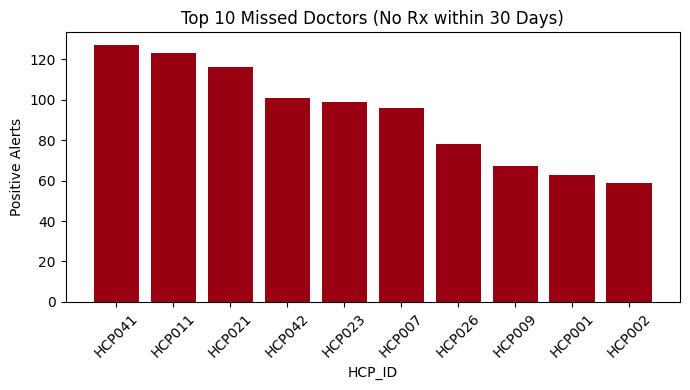

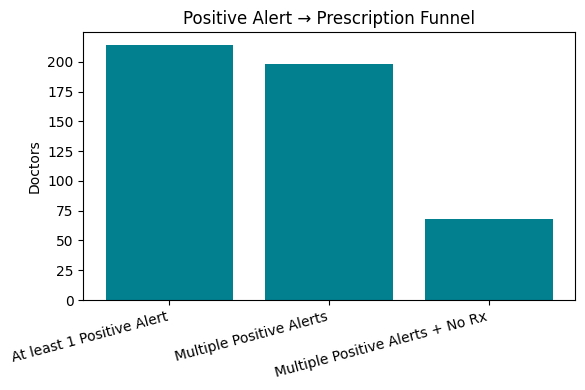

Q2 charts added.


In [64]:
# Q2 Charts
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(top10_missed['HCP_ID'], top10_missed['Positive_Alerts'], color='#990011')
ax.set_title('Top 10 Missed Doctors (No Rx within 30 Days)')
ax.set_xlabel('HCP_ID'); ax.set_ylabel('Positive Alerts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('q2_missed_chart.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(funnel['Stage'], funnel['Doctors'], color='#028090')
ax.set_title('Positive Alert → Prescription Funnel')
ax.set_ylabel('Doctors')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('q2_funnel_chart.png', dpi=150)
plt.show()

wb = load_workbook('Case_Study_Output.xlsx')
ws1 = wb['Q2_Top10_Missed']
ws1.add_image(XLImage('q2_missed_chart.png'), 'H2')

ws2 = wb['Q2_Funnel']
ws2.add_image(XLImage('q2_funnel_chart.png'), 'E2')

wb.save('Case_Study_Output.xlsx')
print("Q2 charts added.")

In [68]:
with pd.ExcelWriter('Case_Study_Output.xlsx',mode='a',engine='openpyxl',if_sheet_exists='replace') as writer:

    q3_complete.to_excel(writer,sheet_name='Q3_Prescription_Mix',index=False)

    competitor_table.to_excel(writer,sheet_name='Q3_Competitor_Drugs',index=False)

print("Q3 saved successfully")

Q3 saved successfully


In [66]:
#top 10 alert-volume HCPs include HCP041, HCP011, HCP021, HCP007, but none of them have any sales records, so when we build top10_sales and group by HCP_ID, they vanish entirely instead of showing up with 0 volume / 0% share.

In [67]:
all_top10 = top10_alerts[['Rank','HCP_ID']]

q3_complete = all_top10.merge(table1,on=['Rank','HCP_ID'],how='left')

q3_complete = q3_complete.fillna(0)

q3_complete

,Rank,HCP_ID,Total_Prescription_Volume,Our_Drug_Share_%,Competitor_Share_%
0,1,HCP041,0.0,0.00,0.00
1,2,HCP011,0.0,0.00,0.00
2,3,HCP019,2277.0,59.11,40.89
3,4,HCP020,570.0,25.44,74.56
4,5,HCP032,2075.0,59.13,40.87
5,6,HCP021,0.0,0.00,0.00
6,7,HCP014,944.0,71.08,28.92
7,8,HCP036,1895.0,64.75,35.25
8,9,HCP022,1363.0,62.00,38.00
9,10,HCP007,0.0,0.00,0.00


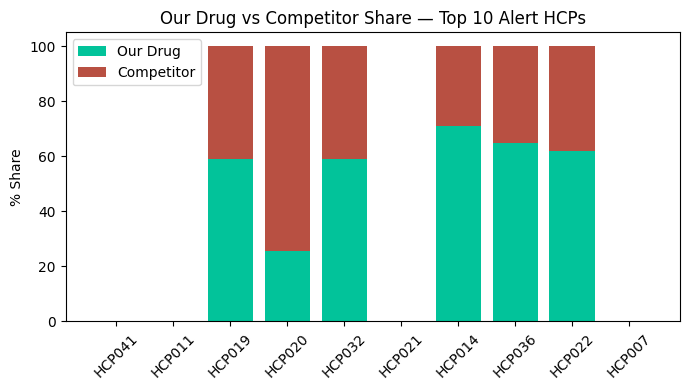

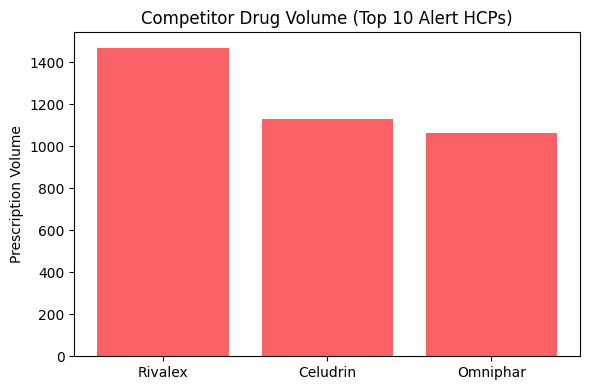

Q3 charts added.


In [69]:
# Q3 Charts
fig, ax = plt.subplots(figsize=(7,4))
ax.bar(q3_complete['HCP_ID'], q3_complete['Our_Drug_Share_%'], label='Our Drug', color='#02C39A')
ax.bar(q3_complete['HCP_ID'], q3_complete['Competitor_Share_%'],
       bottom=q3_complete['Our_Drug_Share_%'], label='Competitor', color='#B85042')
ax.set_title('Our Drug vs Competitor Share — Top 10 Alert HCPs')
ax.set_ylabel('% Share')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('q3_share_chart.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(competitor_table['Drug_Name'], competitor_table['Prescription_Volume'], color='#F96167')
ax.set_title('Competitor Drug Volume (Top 10 Alert HCPs)')
ax.set_ylabel('Prescription Volume')
plt.tight_layout()
plt.savefig('q3_competitor_chart.png', dpi=150)
plt.show()

wb = load_workbook('Case_Study_Output.xlsx')
ws1 = wb['Q3_Prescription_Mix']
ws1.add_image(XLImage('q3_share_chart.png'), 'H2')

ws2 = wb['Q3_Competitor_Drugs']
ws2.add_image(XLImage('q3_competitor_chart.png'), 'F2')

wb.save('Case_Study_Output.xlsx')
print("Q3 charts added.")